In [1]:
from aoespy import *
import xarray as xr
dir='/nobackupp27/afahad/exp/'
data='/nobackupp27/afahad/project/initialization_shock/data/'

/home6/afahad/.local/lib/python3.9/site-packages/aoespy.py:19: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
# ME506=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0506/holding/geosgcm_surf/200505/*surf*200505*z.nc4')
# ME5062=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0506/holding/geosgcm_surf/200506/*surf*200506*z.nc4')
# ME5063=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0506/holding/geosgcm_surf/200507/*surf*200507*z.nc4')
# ME506=xr.concat([ME506,ME5062,ME5063],dim='time')
# ME506P = ME506.PRECTOT.compute()#ds*86400
# ME506O=ME506.OLR.compute()

In [3]:
# ME506P=ME506P.assign_coords(lon=ME506P.lon % 360).sortby('lon')
# ME506O=ME506O.assign_coords(lon=ME506O.lon % 360).sortby('lon')

In [5]:
# dsa=xr.open_mfdataset('/nobackupp27/afahad/exp/GMC90_ref/holding/geosgcm_surf/link/*nc4').OLR

In [6]:
dsa=xr.open_mfdataset('/nobackupp27/afahad/scratch/olr.day.mean.nc').olr.compute()
dsa=dsa[:,::-1,:]
ds=dsa.sel(time=slice('1980','2022'))

In [23]:
olr=ds.sel(time=slice('2010','2022'))[:,::-1,:]

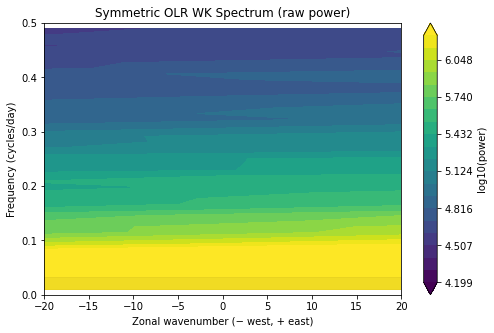

In [33]:
import xarray as xr
import numpy as np
from scipy.signal import detrend, get_window
from scipy.ndimage import uniform_filter
import matplotlib.pyplot as plt

# --- 0) Load OLR ---
# Expect an existing DataArray named `olr` with dims (time, lat, lon)
# If you need to load, uncomment the next line and point to your file.
# olr = xr.open_mfdataset('/nobackupp27/afahad/scratch/olr.day.mean.nc').olr.load()

# --- 1) Remove running mean (121 days) to get anomalies ---
anom = olr - olr.rolling(time=121, center=True, min_periods=60).mean()

# --- 2) Extract tropics and compute symmetric/antisymmetric parts ---
band = anom.sel(lat=slice(-15, 15))
lon = band.lon.values
assert np.allclose(np.diff(lon), lon[1]-lon[0]), "Longitude must be uniformly spaced."

pos = band.lat.where(band.lat > 0, drop=True)
neg = band.lat.where(band.lat < 0, drop=True)
if pos.size == 0 or neg.size == 0:
    raise RuntimeError("No positive/negative latitudes found within ±15°.")

lat_step = float(np.median(np.abs(np.diff(band.lat.values))))
neg_match = xr.DataArray(-pos.values, coords={'lat': pos.values}, dims='lat')

band_p = band.sel(lat=pos)
band_n = band.sel(lat=neg_match, method='nearest').assign_coords(lat=pos.values)

w = np.cos(np.deg2rad(pos.values))
sym = (0.5*(band_p + band_n)).weighted(xr.DataArray(w, coords={'lat':pos.values}, dims='lat')).mean('lat')
anti = (0.5*(band_p - band_n)).weighted(xr.DataArray(w, coords={'lat':pos.values}, dims='lat')).mean('lat')

sym = sym - sym.mean('lon')
anti = anti - anti.mean('lon')

if np.isnan(sym).all() or np.isnan(anti).all():
    raise RuntimeError("Sym/Anti fields are all-NaN after pairing.")

# --- 3) Wheeler–Kiladis spectrum function ---
def wk_spectrum(field, seglen=96, overlap=0.5, nan_frac_max=0.2):
    f = field.sortby('lon')
    step = int(seglen*(1-overlap))
    starts = np.arange(0, f.sizes['time']-seglen+1, step)
    nl = f.sizes['lon']

    wt = get_window('hann', seglen, fftbins=False)
    wl = get_window('hann', nl, fftbins=False)
    W = np.outer(wt, wl)

    acc = None; used = 0
    for s in starts:
        seg = f.isel(time=slice(s, s+seglen)).load()
        if float(seg.isnull().mean()) > nan_frac_max:
            continue
        seg = seg.fillna(seg.mean(("time","lon"), skipna=True))
        seg = seg - seg.mean('lon')
        seg = xr.apply_ufunc(detrend, seg, input_core_dims=[['time']], output_core_dims=[['time']],
                             kwargs={'axis':0, 'type':'linear'}, vectorize=True)
        seg = xr.apply_ufunc(detrend, seg, input_core_dims=[['lon']], output_core_dims=[['lon']],
                             kwargs={'axis':-1, 'type':'constant'}, vectorize=True)
        A = (seg * xr.DataArray(W, coords={'time':seg.time,'lon':seg.lon}, dims=('time','lon'))).values
        F = np.fft.fftshift(np.fft.fft2(A, axes=(0,1)))
        P = np.abs(F)**2
        acc = P if acc is None else acc + P
        used += 1

    if used == 0:
        raise RuntimeError("No valid segments for spectrum.")

    Pavg = acc / used
    freqs = np.fft.fftshift(np.fft.fftfreq(seglen, d=1.0))
    k = np.fft.fftshift(np.arange(-nl//2, nl//2))
    spec = xr.DataArray(Pavg[freqs>0, :], coords={'freq_cpd': freqs[freqs>0], 'k': k}, dims=('freq_cpd','k'))
    return spec.where(spec['k'] != 0)

spec_sym = wk_spectrum(sym)
# Only compute SYMMETRIC spectrum (no background division)
spec_sym = wk_spectrum(sym)

# --- 4) Plot raw symmetric power (log10) ---
fig, ax = plt.subplots(figsize=(8,5))
Z = np.log10(np.where(np.isfinite(spec_sym), spec_sym, np.nan))
cs = ax.contourf(spec_sym['k'], spec_sym['freq_cpd'], Z,
                 levels=np.linspace(np.nanpercentile(Z,5), np.nanpercentile(Z,95), 21),
                 extend='both')
plt.colorbar(cs, ax=ax, label='log10(power)')
ax.set(xlim=(-20,20), ylim=(0,0.5), xlabel='Zonal wavenumber (− west, + east)',
       ylabel='Frequency (cycles/day)', title='Symmetric OLR WK Spectrum (raw power)')
# highlight typical MJO band
ax.axhspan(1/96, 1/30, color='k', alpha=0.05)
plt.show()



In [86]:
# ds=ME506O.sel(lat=slice(-15,15)).resample(time="D").mean()  

In [95]:
ds=dsa.sel(lat=slice(-15,15)).assign_coords(lon=dsa.lon % 360).sortby('lon').compute()

In [97]:
cmap = plt.get_cmap('PuBuGn', 18)

Computing space-time power spectrum...
Computation complete.
Creating background spectrum and computing ratio...
Ratio computation complete.
Generating plot...


/var/tmp/pbs.22746178.pbspl1.nas.nasa.gov/ipykernel_90271/2209926832.py:331: RuntimeWarning: divide by zero encountered in true_divide
  return 1 / p


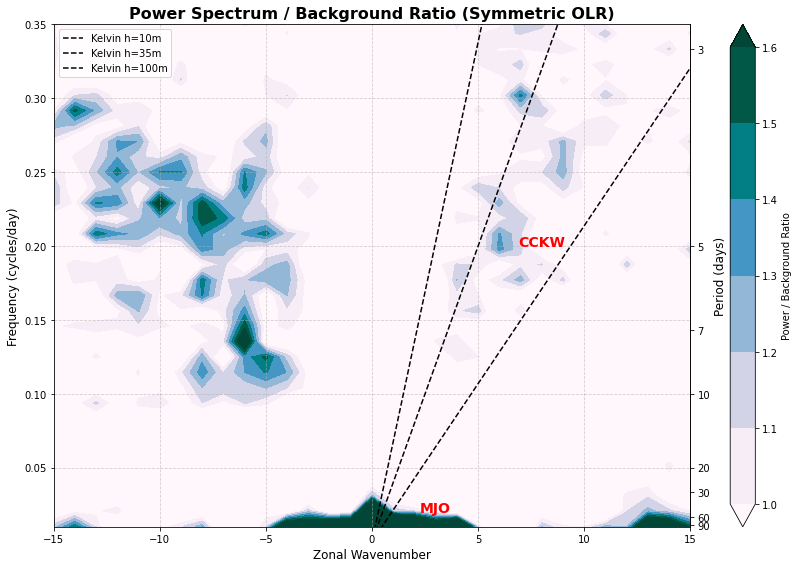

Plot generated.


In [100]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import convolve2d
from matplotlib.colors import ListedColormap

# --- Functions from spacetime.py ---
# The following functions are adapted from the provided spacetime.py file
# to make this script self-contained for spectral analysis.

def tapertozero(ts,N,nmi,nn,tp):
    """Tapers the ends of a time series to zero."""
    if ((N<25) | (nn<25)): return ts
    if ((nmi+nn-1)>N): return ts
    for i in np.arange(0,N):
        j=i-nmi+2
        if ((j<=0) | (j>nn)): ts[i]=0.
        elif (j<=tp): ts[i]= ts[i]*0.5*(1.-np.cos((j-1)*np.pi/tp))
        elif ((j>(nn-tp)) & (j<=nn)): ts[i]= ts[i]*0.5*(1.-np.cos((nn-j)*np.pi /tp))
    return ts

def get_symmasymm(X, lat, opt=False):
    """Splits data into symmetric and anti-symmetric parts."""
    if opt == 'symm':
        x = (X + X.reindex(lat=X['lat'][::-1])) / 2
        return x.sel(lat=slice(0, 90))
    elif opt == 'asymm':
        x = (X - X.reindex(lat=X['lat'][::-1])) / 2
        return x.sel(lat=slice(-90, -1))
    else:
        print("Please provide a valid option: symm or asymm.")
        return None

def mjo_cross_segment(XX, YY, opt='both', optS='sum'):
    """Computes the cross-spectra for one time segment."""
    NT, NM, NL = XX.shape
    xlat = XX['lat']
    ylat = YY['lat']
    XX_T = np.transpose(XX, axes=[1, 2, 0])
    YY_T = np.transpose(YY, axes=[1, 2, 0])
    Xfft = np.fft.rfft2(XX_T, axes=(1, 2)) / (NL * NT)
    Yfft = np.fft.rfft2(YY_T, axes=(1, 2)) / (NL * NT)
    Xfft = np.fft.fftshift(np.transpose(Xfft, axes=[2, 0, 1]), axes=2)
    Yfft = np.fft.fftshift(np.transpose(Yfft, axes=[2, 0, 1]), axes=2)
    
    if NT % 2 == 1: nfreq = int((NT + 1) / 2)
    else: nfreq = int(NT / 2) + 1
    
    PXYsymm = np.conj(Xfft[:, xlat > 0, :]) * Yfft[:, ylat > 0, :]
    PXsymm = 2 * np.sum(np.square(np.abs(Xfft[:, xlat > 0, :])), axis=1)
    PYsymm = 2 * np.sum(np.square(np.abs(Yfft[:, ylat > 0, :])), axis=1)
    CXYsymm = 2 * np.sum(np.real(PXYsymm), axis=1)
    QXYsymm = 2 * np.sum(np.imag(PXYsymm), axis=1)
    
    PXsymm, PYsymm, CXYsymm, QXYsymm = [arr[:nfreq, ::-1] for arr in [PXsymm, PYsymm, CXYsymm, QXYsymm]]
    
    nwave = NL + (1 if NL % 2 == 0 else 0)
    STC = np.zeros([8, nfreq, nwave], dtype='double')
    
    if NL % 2 == 0:
        STC[0, :, 1:NL + 1] = PXsymm
        STC[1, :, 1:NL + 1] = PYsymm
        STC[2, :, 1:NL + 1] = CXYsymm
        STC[3, :, 1:NL + 1] = QXYsymm
        STC[:, :, 0] = STC[:, :, NL]
    else:
        STC[0, :, :] = PXsymm
        STC[1, :, :] = PYsymm
        STC[2, :, :] = CXYsymm
        STC[3, :, :] = QXYsymm
        
    return STC

def mjo_cross_coh2pha(STC):
    """Computes coherence squared and phase."""
    PX, PY, CXY, QXY = STC[0, :, :], STC[1, :, :], STC[2, :, :], STC[3, :, :]
    with np.errstate(divide='ignore', invalid='ignore'):
        COH2 = (CXY**2 + QXY**2) / (PX * PY)
    STC[4, :, :] = COH2
    STC[5, :, :] = np.arctan2(QXY, CXY)
    return STC

def mjo_cross(X, Y, segLen, segOverLap):
    """Main function to compute cross-spectra by segmenting the data."""
    ntim, nlat, mlon = X.shape
    x = X.copy()
    y = Y.copy()
    x.values = signal.detrend(x, 0)
    y.values = signal.detrend(y, 0)
    
    window = tapertozero(np.ones(segLen, dtype='double'), segLen, 1, segLen, 10)
    window_3d = np.tile(window[:, np.newaxis, np.newaxis], (1, nlat, mlon))

    nfreq = int(segLen / 2) + 1 if segLen % 2 == 0 else int((segLen + 1) / 2)
    nwave = mlon + 1 if mlon % 2 == 0 else mlon
    
    STC_sum = np.zeros([8, nfreq, nwave], dtype='double')
    kseg = 0
    for ntStrt in range(0, ntim - segLen + 1, segLen - segOverLap):
        ntLast = ntStrt + segLen
        XX = x[ntStrt:ntLast, :, :].copy()
        YY = y[ntStrt:ntLast, :, :].copy()
        XX.values *= window_3d
        YY.values *= window_3d
        STC_sum += mjo_cross_segment(XX, YY)
        kseg += 1
        
    STC = STC_sum / kseg if kseg > 0 else STC_sum
    STC = mjo_cross_coh2pha(STC)
    
    wave = np.arange(-int(mlon / 2), int(mlon / 2) + 1, 1.)
    freq = np.linspace(0, 0.5, num=nfreq)
    
    return {'STC': STC, 'freq': freq, 'wave': wave, 'nseg': kseg}

def create_background(power_spec):
    """
    Creates a smooth background spectrum using a two-pass smoothing method.
    This is more robust against sharp peaks than a single 2D filter.
    
    Args:
        power_spec (np.ndarray): The 2D power spectrum (frequency x wavenumber).
                           
    Returns:
        np.ndarray: The smoothed background spectrum.
    """
    # First pass: smooth heavily in the frequency direction (axis 0)
    freq_smoothed = np.apply_along_axis(
        lambda m: np.convolve(m, np.ones(15)/15, mode='same'), 
        axis=0, 
        arr=power_spec
    )
    
    # Second pass: smooth the result heavily in the wavenumber direction (axis 1)
    background = np.apply_along_axis(
        lambda m: np.convolve(m, np.ones(15)/15, mode='same'), 
        axis=1, 
        arr=freq_smoothed
    )
    
    return background

def kelvin_dispersion(wavenumbers, h_eq):
    """
    Calculates the theoretical dispersion curve for a Kelvin wave.
    
    Args:
        wavenumbers (np.ndarray): Array of zonal wavenumbers.
        h_eq (float): Equivalent depth in meters.
        
    Returns:
        np.ndarray: Frequencies in cycles per day.
    """
    g = 9.81  # gravity
    Re = 6.371e6  # Earth radius
    
    # Convert zonal wavenumber to physical wavenumber (rad/m)
    k = (2 * np.pi * wavenumbers) / (2 * np.pi * Re)
    
    # Calculate angular frequency (rad/s)
    omega = np.sqrt(g * h_eq) * k
    
    # Convert frequency from rad/s to cycles/day
    freq_cpd = (omega / (2 * np.pi)) * 86400
    
    return freq_cpd

def rossby_dispersion(wavenumbers, h_eq, n=1):
    """
    Calculates the theoretical dispersion curve for an n=1 equatorial Rossby wave.
    
    Args:
        wavenumbers (np.ndarray): Array of zonal wavenumbers.
        h_eq (float): Equivalent depth in meters.
        n (int): Meridional mode number (default is 1 for the gravest mode).
        
    Returns:
        np.ndarray: Frequencies in cycles per day.
    """
    g = 9.81
    Re = 6.371e6
    omega_earth = 7.292e-5
    beta = 2 * omega_earth / Re
    
    # Convert zonal wavenumber to physical wavenumber (rad/m)
    k = (2 * np.pi * wavenumbers) / (2 * np.pi * Re)
    
    # Phase speed
    c = np.sqrt(g * h_eq)
    
    # Calculate angular frequency (rad/s) for Rossby waves
    # ω = -βk / (k² + (2n+1)β/c)
    denominator = k**2 + ((2 * n + 1) * beta / c)
    with np.errstate(divide='ignore', invalid='ignore'):
        omega_rad_s = -beta * k / denominator
    
    # Convert frequency from rad/s to cycles/day
    freq_cpd = (omega_rad_s / (2 * np.pi)) * 86400
    
    return freq_cpd


if __name__ == '__main__':
    # --- 1. User Data Assumption ---
    # This script assumes you have an xarray DataArray named `ds` loaded.
    # `ds` should contain your daily OLR data with dimensions (time, lat, lon).
    try:
        ds
        arange = np.arange
    except NameError:
        print("Variable 'ds' not found. Creating placeholder data for demonstration.")
        lons = np.linspace(0, 359, 360)
        lats = np.linspace(-90, 90, 181)
        time_len = 256
        ds = xr.DataArray(
            np.random.rand(time_len, len(lats), len(lons)),
            dims=('time', 'lat', 'lon'),
            coords={'time': np.arange(time_len), 'lat': lats, 'lon': lons}
        )
        arange = np.arange

    # --- Create Custom Colormap ---
    # This colormap is designed to replicate the one in the user-provided image.
    colors = [
        '#ffffff', '#cae1f1', '#a6cee3', '#7fbc41', '#b2df8a', 
        '#ffff99', '#fdbf6f', '#ff7f00', '#e31a1c'
    ]
    custom_cmap = ListedColormap(colors)


    # --- 2. Compute Space-Time Power Spectrum ---
    print("Computing space-time power spectrum...")
    # Parameters for spectral analysis
    segLen = 96      # Segment length in days
    segOverLap = 48  # Overlap between segments

    
    
    
    # We compute the spectrum of the data with itself (X=Y)
    # The data needs to be lat-limited for symmetric/asymmetric separation
    ds_15ns = ds.sel(lat=slice(-15, 15))
    
    spec_results = mjo_cross(ds_15ns, ds_15ns, segLen, segOverLap)
    
    # Extract results
    STC = spec_results['STC']
    freq = spec_results['freq']
    wave = spec_results['wave']
    
    # We will plot the symmetric power spectrum of the OLR data
    power_spectrum_symm = STC[0, :, :]
    
    print("Computation complete.")

    # --- 3. Create Background and Compute Ratio ---
    print("Creating background spectrum and computing ratio...")
    # Use the new two-pass smoothing function
    background_spectrum = create_background(power_spectrum_symm)
    
    # To avoid division by zero, we set the ratio to 1 where the background is negligible.
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio_spectrum = power_spectrum_symm / background_spectrum
        ratio_spectrum[background_spectrum < 1e-5] = 1.0
    
    print("Ratio computation complete.")

    # --- 4. Create the Power Spectrum to Background Ratio Plot ---
    print("Generating plot...")
    fig, ax = plt.subplots(figsize=(12, 8))

    
    
    
    
    
    
    
    
    
    # Define contour levels for the ratio plot.
    levels = arange(1, 1.61, .1)
    #levels = 20
    
    # Create the plot using contourf
    cf = ax.contourf(wave, freq, ratio_spectrum, levels=levels, cmap=cmap, extend='both')
    
    # Add labels and title
    ax.set_xlabel('Zonal Wavenumber', fontsize=12)
    ax.set_ylabel('Frequency (cycles/day)', fontsize=12)
    ax.set_title('Power Spectrum / Background Ratio (Symmetric OLR)', fontsize=16, fontweight='bold')
    
    # Set plot limits as requested
    ax.set_xlim(-15, 15)
    ax.set_ylim(0.01, 0.35)
    
    # Add a colorbar
    fig.colorbar(cf, ax=ax, label='Power / Background Ratio')
    
    # --- Add Kelvin and Rossby Wave Dispersion Curves ---
    h_eq_values = [10, 35, 100]
    wavenumbers_for_plot = np.linspace(-20, 20, 100)
    
    # Plot Kelvin Waves
    for h in h_eq_values:
        kelvin_freq = kelvin_dispersion(wavenumbers_for_plot, h)
        ax.plot(wavenumbers_for_plot, kelvin_freq, color='black', linestyle='--', 
                linewidth=1.5, label=f'Kelvin h={h}m')

#     # Plot Rossby Waves (n=1)
#     for h in h_eq_values:
#         rossby_freq = rossby_dispersion(wavenumbers_for_plot, h)
#         ax.plot(wavenumbers_for_plot, rossby_freq, color='gray', linestyle=':', 
#                 linewidth=2, label=f'Rossby h={h}m')

    ax.legend(loc='upper left')

    # --- Add MJO and CCKW Text Labels ---
    ax.text(3, 0.02, 'MJO', color='red', fontsize=14, fontweight='bold', ha='center')
    ax.text(8, 0.2, 'CCKW', color='red', fontsize=14, fontweight='bold', ha='center')
    
    # --- Add secondary y-axis for Period in Days ---
    def freq_to_period(f):
        # Inverse of frequency (1/f), handling f=0
        with np.errstate(divide='ignore'):
            return 1 / f

    def period_to_freq(p):
        # Inverse of period (1/p)
        return 1 / p

    secax_y = ax.secondary_yaxis('right', functions=(freq_to_period, period_to_freq))
    secax_y.set_ylabel('Period (days)', fontsize=12)

    # Set specific ticks for the period axis
    periods_to_show = [90, 60, 30, 20, 10, 7, 5, 3, 2]
    secax_y.set_ticks(periods_to_show)
    
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
    print("Plot generated.")


In [104]:
ds

<xarray.DataArray 'OLR' (time: 1341, lat: 31, lon: 360)>
array([[[291.40564, 294.3885 , 295.08636, ..., 286.807  , 289.16977,
         289.13928],
        [292.26614, 295.00018, 296.6914 , ..., 288.8398 , 290.11578,
         290.59857],
        [292.7714 , 294.83536, 296.27924, ..., 290.03033, 289.94742,
         291.09613],
        ...,
        [310.65814, 310.1397 , 309.2533 , ..., 313.3399 , 312.4448 ,
         311.1916 ],
        [318.21027, 317.0174 , 315.42014, ..., 320.4604 , 319.75613,
         319.1101 ],
        [324.3263 , 323.23816, 321.33252, ..., 327.5572 , 325.9367 ,
         325.008  ]],

       [[290.78625, 294.7891 , 297.7898 , ..., 286.14157, 289.29254,
         289.3685 ],
        [292.36533, 295.95123, 298.9881 , ..., 287.80377, 290.34842,
         291.5956 ],
        [294.05612, 296.64917, 299.47852, ..., 289.9685 , 290.79147,
         292.69067],
...
        [303.0618 , 303.4776 , 303.52734, ..., 305.1422 , 303.69122,
         302.9502 ],
        [305.2042 , 305.32803, 305.2737 , ..., 307.03394, 305.44284,
         304.91934],
        [309.1304 , 309.3159 , 309.608  , ..., 309.55478, 307.9672 ,
         308.3885 ]],

       [[279.3101 , 278.34323, 277.5719 , ..., 284.3057 , 281.3192 ,
         279.87482],
        [279.5256 , 277.77707, 276.0155 , ..., 282.56882, 280.1344 ,
         279.65582],
        [279.62415, 277.20914, 272.7549 , ..., 282.31625, 280.03445,
         279.43677],
        ...,
        [308.24808, 308.98834, 309.66846, ..., 306.85455, 306.95966,
         307.5654 ],
        [308.10135, 309.75906, 311.68808, ..., 305.34915, 305.3496 ,
         306.49133],
        [311.01974, 313.941  , 316.23688, ..., 306.0734 , 306.18738,
         308.0307 ]]], dtype=float32)
Coordinates:
  * lon      (lon) float64 0.0 1.0 2.0 3.0 4.0 ... 355.0 356.0 357.0 358.0 359.0
  * lat      (lat) float64 -15.0 -14.0 -13.0 -12.0 -11.0 ... 12.0 13.0 14.0 15.0
  * time     (time) datetime64[ns] 2005-05-01T12:00:00 ... 2008-12-31T12:00:00
Attributes:
    fmissing_value:  1000000000000000.0
    long_name:       upwelling_longwave_flux_at_toa
    regrid_method:   bilinear
    standard_name:   upwelling_longwave_flux_at_toa
    units:           W m-2
    valid_range:     [-1.e+15  1.e+15]
    vmax:            1000000000000000.0
    vmin:            -1000000000000000.0

In [69]:
import wk_spectra

In [75]:
sym.lon.size 

144

In [57]:
ds=ds.assign_coords(lon=ds.lon % 360).sortby('lon')

NameError: name 'ds' is not defined

In [185]:
from scipy import signal

In [186]:
# plt.figure(figsize=(12,4.5))
# clf=arange(10,50,5)
# (ds).sel(time=slice('2005-05-05','2005-05-13')).plot.contourf(cmap='PuBuGn',extend='max')
# plt.title('(b) Omega500 spike hovmollar diagram',fontsize=12,fontweight='bold')
# plt.xticks(ds.lon[::20].data,["140°E", "160°E", "180°E", "160°W", "140°W", "120°W",  "100°W"]);
# #plt.savefig('hovmollar.png',dpi=200)

In [187]:
zonal_mean = ds.mean(axis=1)

# 2. Subtract the zonal mean from the data.
# We use np.newaxis to make the zonal_mean array broadcast correctly across the longitudes.
# This removes the spatial average from each time step.
data_anomalies = ds - zonal_mean

# 3. NOW, you can proceed with the rest of your analysis using the anomaly data.
detrended_anomalies = signal.detrend(data_anomalies, axis=0)
spectral_field = np.fft.fft2(detrended_anomalies)


In [188]:
spectral_field_shifted = np.fft.fftshift(spectral_field)

In [189]:
ntime=len(ds)
dt = 1
nlon=len(ds.lon)
earth_radius = 6378137.0  # Earth's equatorial radius in meters
seconds_in_a_day = 86400.0


In [190]:
freqs = np.fft.fftshift(np.fft.fftfreq(ntime, d=dt))
k_wavenums = np.fft.fftshift(np.fft.fftfreq(nlon))

# Initialize an empty mask of zeros
filter_mask = np.zeros_like(spectral_field_shifted)

# Define the boundaries for the Kelvin wave filter
# and set the corresponding elements in the mask to 1
# This is where you translate the "Kelvin" box from the diagram into array indices
for i, freq in enumerate(freqs):
    for j, k in enumerate(k_wavenums):
        period = 1 / freq if freq != 0 else np.inf
        phase_speed = (freq / k) * earth_radius if k != 0 else np.inf

        # Conditions to create the filter mask
        is_eastward = k > 0
        is_correct_period = 2.5 < period < 30
        is_correct_speed = 10 < phase_speed < 25

        if is_eastward and is_correct_period and is_correct_speed:
            filter_mask[i, j] = 1.0 # Keep this wave

In [191]:
filtered_spectral_field = spectral_field_shifted * filter_mask

# Unshift and apply the inverse FFT
filtered_spectral_field_unshifted = np.fft.ifftshift(filtered_spectral_field)
kelvin_wave_data = np.fft.ifft2(filtered_spectral_field_unshifted)

# The result will be a complex array; take the real part
isolated_k_wave = kelvin_wave_data.real

In [248]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft2, fftshift, fftfreq
from scipy import signal

def k_omega_analysis(data_array):
    """
    Performs a wavenumber-frequency (k-ω) analysis on a given xarray DataArray.

    Args:
        data_array (xr.DataArray): The input DataArray to analyze.
                                   Must have 'time' and 'lon' dimensions.
    """
    # --- 1. Data Preparation ---
    # The input is already a DataArray
    data = data_array

    # Ensure dimensions are named correctly
    if not all(dim in data.dims for dim in ['time', 'lon']):
        print("Error: DataArray must have 'time' and 'lon' dimensions.")
        return

    # Ensure data is in (time, lon) order for subsequent operations.
    # .copy() ensures the underlying numpy array has the correct memory layout.
    print("Ensuring data is in ('time', 'lon') order...")
    data = data.transpose('time', 'lon').copy()

    # Get dimensions
    nt, nx = data.sizes['time'], data.sizes['lon']
    
    # --- 2. Pre-processing ---
    # a) Detrend the data along the time axis to remove linear trends
    #    This prevents a spike at zero frequency.
    print("Detrending data...")
    data_detrended = xr.apply_ufunc(
        signal.detrend,
        data,
        input_core_dims=[['time']],
        output_core_dims=[['time']],
        kwargs={'axis': -1},
        keep_attrs=True
    )

    # b) Apply a tapering window using xarray's dimension-aware broadcasting
    print("Applying Hanning window...")
    # Create windows as DataArrays to leverage xarray's broadcasting
    time_window = xr.DataArray(signal.windows.hann(nt), dims=['time'], coords={'time': data.coords['time']})
    lon_window = xr.DataArray(signal.windows.hann(nx), dims=['lon'], coords={'lon': data.coords['lon']})
    
    # xarray handles the broadcasting by dimension name, which is more robust
    combined_window = time_window * lon_window
    data_windowed = data_detrended * combined_window

    # --- 3. 2D Fourier Transform ---
    print("Performing 2D FFT...")
    # Perform the 2D FFT and shift the zero-frequency/wavenumber to the center
    # We use .values to pass a numpy array to fft2, which requires correct dimension order
    sp = fftshift(fft2(data_windowed.values, axes=(0, 1)))

    # Calculate the Power Spectral Density (PSD)
    # Power is the squared magnitude of the complex FFT result.
    psd = np.abs(sp)**2

    # --- 4. Create Frequency and Wavenumber Axes ---
    # The time step is assumed to be 1 day. Modify if your data is different (e.g., 1/4 for 6-hourly)
    time_step_days = 1
    
    # Wavenumber axis (cycles per Earth circumference)
    # Scaled by the number of longitude points
    k = fftshift(fftfreq(nx)) * nx
    
    # Frequency axis (cycles per day)
    # Scaled by the time step
    f = fftshift(fftfreq(nt, d=time_step_days))

    # --- 5. Plotting ---
    print("Generating plot...")
    fig, ax = plt.subplots(figsize=(12, 8))

    # Add a small epsilon to avoid log10(0)
    epsilon = 1e-12
    log_psd = np.log10(psd + epsilon)
    
    # Define contour levels to span a few orders of magnitude for clarity
    max_power = np.max(log_psd)
    


    # Create an xarray.DataArray from the results for robust plotting
    # The first axis of the FFT result corresponds to frequency, the second to wavenumber.
    psd_da = xr.DataArray(
        log_psd.T,
        dims=['frequency', 'wavenumber'],
        coords={'frequency': f, 'wavenumber': k}
    )
    
    
    
    
    levels = np.linspace(max_power - 2.5, max_power+.5, 15)

    #levels=np.arange(7,9.51,.25)
    # Use xarray's built-in plotting which handles coordinates correctly
    psd_da.plot.contourf(
        ax=ax,
        x='wavenumber',
        y='frequency',
        levels=levels,
        cmap='OrRd',
        extend='max',
        cbar_kwargs={'label': 'log10(Power)'}
    )

    # --- 6. Overlay Theoretical Kelvin Wave Dispersion Curves ---
    g = 9.81  # gravity (m/s^2)
    a = 6.371e6 # Earth radius (m)
    
    # Equivalent depths for CCKWs
    equivalent_depths = [12, 25, 50]
    
    # Wavenumbers to plot over (planetary scales)
    k_plot = np.arange(0.1, 15.1, 0.1)
    
    for he in equivalent_depths:
        # Phase speed: c = sqrt(g * he)
        c = np.sqrt(g * he)
        # Frequency: omega = c * k_wave / a
        # k_wave is the zonal wavenumber
        # Convert from rad/s to cycles/day
        omega_hz = (c * k_plot) / a
        omega_cpd = omega_hz * (60*60*24) / (2*np.pi)
        
        ax.plot(k_plot, omega_cpd, color='darkblue', linestyle='--', label=f'Kelvin (he={he}m)')
        ax.legend(loc=1)
        # Plot for westward propagation as well, though Kelvin waves are eastward
        ax.plot(-k_plot, omega_cpd, color='darkblue', linestyle=':')


    # --- 7. Final Plot Adjustments ---
    ax.set_title('Wavenumber-Frequency Power Spectrum (Eastward vs. Westward)', fontsize=16)
    ax.set_xlabel('Zonal Wavenumber (k)', fontsize=12)
    ax.set_ylabel('Frequency (cycles/day)', fontsize=12)
    
    # Focus on physically relevant frequencies/wavenumbers
    ax.set_xlim(-15, 15)
    # Set lower y-limit to a small positive number to avoid division by zero
    ax.set_ylim(1e-6, 0.5) # Use a tiny positive number instead of zer

    # Add a secondary y-axis for Period
    # Use np.where for vectorized conditional logic to avoid ValueError
    forward_transform = lambda x: np.where(x != 0, 1/x, np.inf)
    inverse_transform = lambda x: np.where(x != 0, 1/x, np.inf)
    ax2 = ax.secondary_yaxis('right', functions=(forward_transform, inverse_transform))
    ax2.set_ylabel('Period (days)', fontsize=12)
    ax2.set_yticks([2, 3, 5, 10, 20, 30, 60])

    ax.grid(True, linestyle=':', alpha=0.5)

    
    # Add a vertical line at k=0 to separate eastward/westward
    ax.axvline(0, color='darkblue', linewidth=1)
    plt.tight_layout()
    plt.savefig('power_scpectra.png',dpi=150)
    plt.show()


Ensuring data is in ('time', 'lon') order...
Detrending data...
Applying Hanning window...
Performing 2D FFT...
Generating plot...


/var/tmp/pbs.22740821.pbspl1.nas.nasa.gov/ipykernel_57548/3455777750.py:153: RuntimeWarning: divide by zero encountered in true_divide
  inverse_transform = lambda x: np.where(x != 0, 1/x, np.inf)


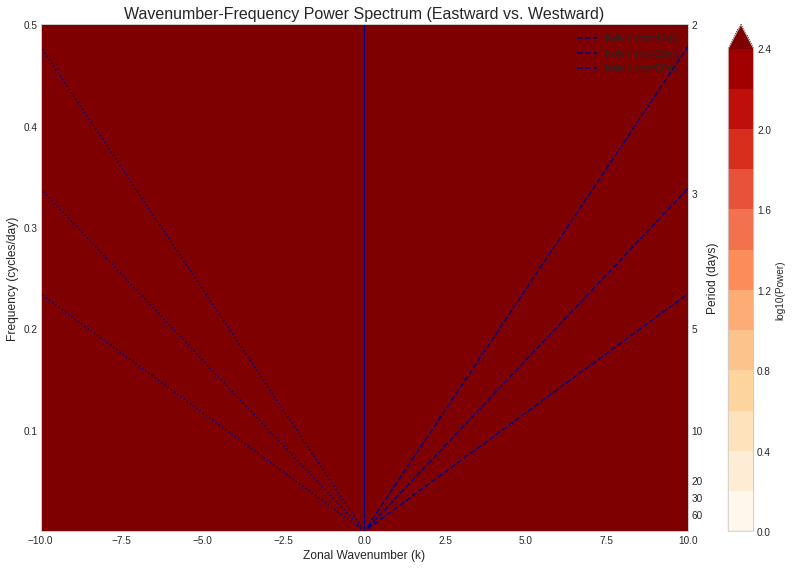

In [249]:
k_omega_analysis(ds.sel(lat=slice(-10,10)).mean(dim='lat'))